In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
digits = datasets.load_digits()
type(digits)

sklearn.utils._bunch.Bunch

In [3]:
x = digits.data
y = digits.target


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
svm = SVC(kernel='rbf', C=10, gamma=0.05)
svm.fit(X_train, y_train)

SVC(C=10, gamma=0.05)

In [7]:
y_pred = svm.predict(X_test)

In [8]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Accuracy: 0.9722


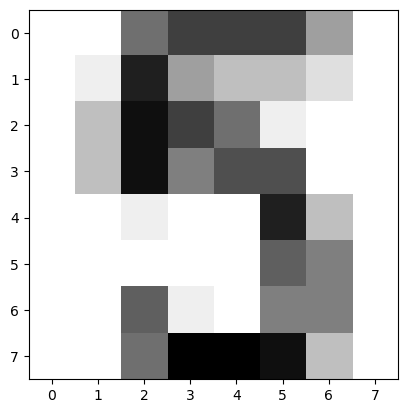

In [9]:
plt.imshow(digits.images[1010], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

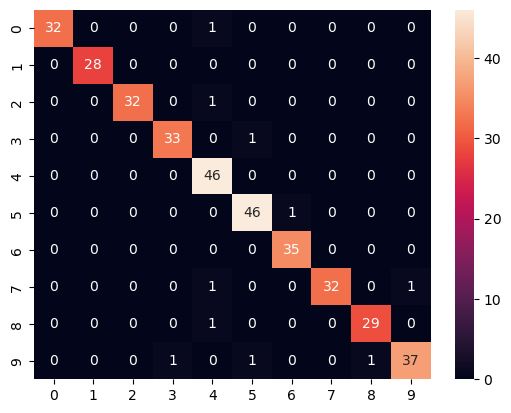

In [10]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

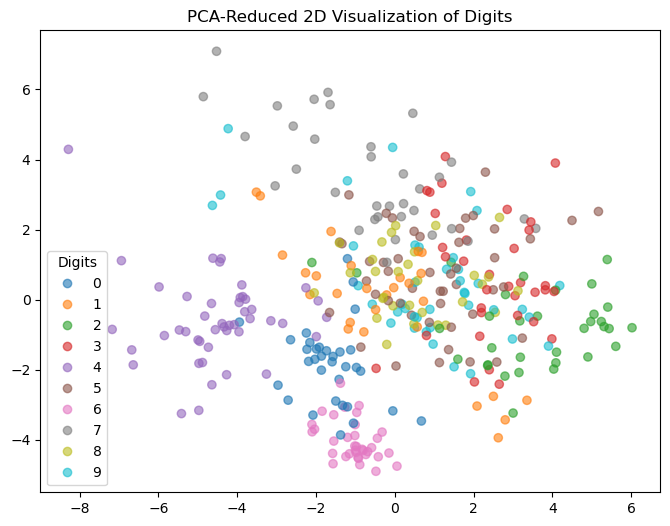

In [11]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

# Train SVM on 2D (for visualization only)
svm_2d = SVC(kernel='rbf', C=10, gamma=0.05)
svm_2d.fit(X_train_2D, y_train)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, cmap='tab10', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title('PCA-Reduced 2D Visualization of Digits')
plt.show()

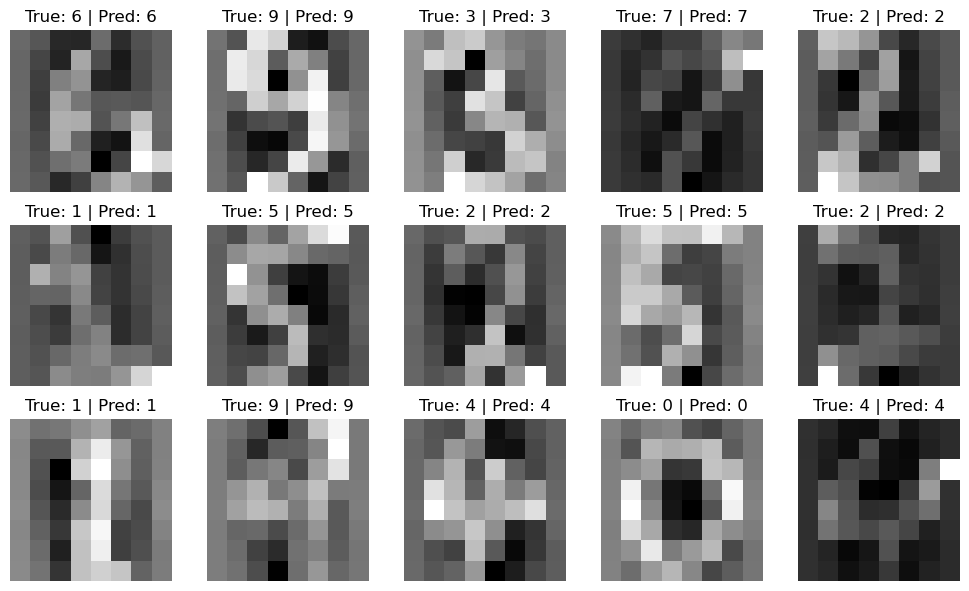

In [12]:
import numpy as np

# Plot 15 sample predictions
fig, axes = plt.subplots(3, 5, figsize=(10,6))
for ax, image, true_label, pred_label in zip(
    axes.ravel(),
    X_test,
    y_test,
    y_pred
):
    ax.imshow(image.reshape(8,8), cmap='gray')
    ax.set_title(f'True: {true_label} | Pred: {pred_label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

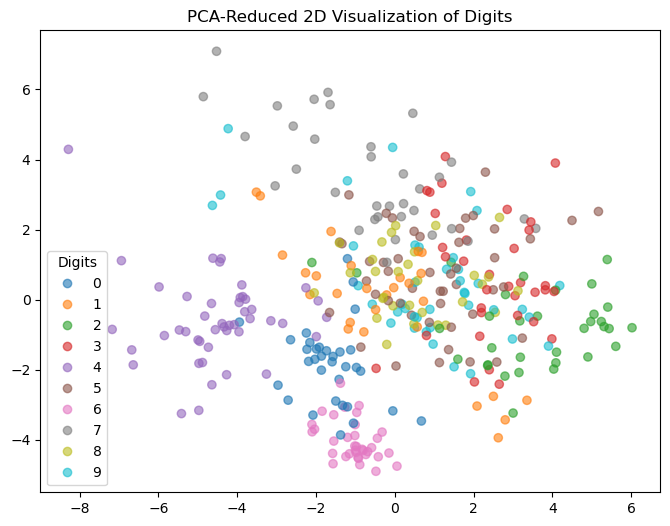

In [13]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

# Train SVM on 2D (for visualization only)
svm_2d = SVC(kernel='rbf', C=10, gamma=0.05)
svm_2d.fit(X_train_2D, y_train)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, cmap='tab10', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title('PCA-Reduced 2D Visualization of Digits')
plt.show()

In [14]:
with open('svm_digit_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

print("✅ SVM model saved as 'svm_digit_model.pkl'")

✅ SVM model saved as 'svm_digit_model.pkl'
